# RAG Chunking Strategies Lab
**Comparing chunking approaches for Podcast Transcripts and PDF Documents**

This notebook implements and compares multiple chunking strategies:
- Fixed-Size Chunking
- Recursive Character Chunking
- Token-Based Chunking
- Semantic Chunking (Advanced)


## Step 1: Setup and Installation

In [3]:
!pip install langchain langchain-text-splitters pypdf2 tiktoken \
             matplotlib pandas -q

In [4]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from io import BytesIO
from pathlib import Path
from collections import Counter

# LangChain splitters
from langchain_text_splitters import (
    CharacterTextSplitter,
    RecursiveCharacterTextSplitter,
    TokenTextSplitter,
)

import tiktoken

print("✅ All imports successful")

✅ All imports successful


## Step 2: Load Content Sources

We use:
- A **podcast transcript** (sample Trustworthy AI conversation text)
- A **PDF document** on Trustworthy AI (fetched from a public source)

If you have your own files, replace the loading cells below.

In [48]:
import urllib.request
import os
import zipfile
import imageio_ffmpeg

ffmpeg_dir = os.path.dirname(imageio_ffmpeg.get_ffmpeg_exe())

# Download ffprobe windows build
zip_path = os.path.join(ffmpeg_dir, "ffprobe.zip")
urllib.request.urlretrieve(
    "https://github.com/BtbN/FFmpeg-Builds/releases/download/latest/ffmpeg-master-latest-win64-gpl.zip",
    zip_path
)

# Extract only ffprobe.exe
with zipfile.ZipFile(zip_path, 'r') as z:
    for name in z.namelist():
        if name.endswith("ffprobe.exe"):
            z.extract(name, ffmpeg_dir)
            # Move to expected location
            extracted = os.path.join(ffmpeg_dir, name)
            target = os.path.join(ffmpeg_dir, "ffprobe.exe")
            os.rename(extracted, target)
            print("✅ ffprobe.exe extracted to:", target)
            break

os.remove(zip_path)
print("ffprobe exists now:", os.path.exists(os.path.join(ffmpeg_dir, "ffprobe.exe")))

✅ ffprobe.exe extracted to: c:\Users\eliza\anaconda3\Lib\site-packages\imageio_ffmpeg\binaries\ffprobe.exe
ffprobe exists now: True


In [49]:
import numpy as np
import whisper
from pydub import AudioSegment
import imageio_ffmpeg, os

ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()
ffmpeg_dir = os.path.dirname(ffmpeg_exe)

AudioSegment.converter = ffmpeg_exe
AudioSegment.ffmpeg    = ffmpeg_exe
AudioSegment.ffprobe   = os.path.join(ffmpeg_dir, "ffprobe.exe")

audio_path = r"C:\Users\eliza\OneDrive\Documents\W8_LAB_RAG_Chunk-Podcast\Document\The_Blueprint_For_Trustworthy_AI.m4a"
audio = AudioSegment.from_file(audio_path, format="m4a")
audio = audio.set_frame_rate(16000).set_channels(1)

samples = np.array(audio.get_array_of_samples()).astype(np.float32)
samples /= np.iinfo(audio.array_type).max

model = whisper.load_model("base")
result = model.transcribe(samples)

PODCAST_TEXT = result["text"]
print(f"✅ Transcript extracted: {len(PODCAST_TEXT):,} characters")
print(PODCAST_TEXT[:500])

✅ Transcript extracted: 16,399 characters
 So imagine for a second you're driving across a, I don't know, a massive suspension bridge. Okay. You don't pull over halfway across, get out and demand to see the blueprints, right? You don't interview the welding crew. No, you just, you trust it. You just drive, you trust the bridge, you trust the engineering standards, the inspections, the laws that say this thing won't fail. Right. It's trust in the infrastructure. It's invisible, but it's there. Exactly. But now let's put gears. Think abou


In [55]:
!pip install pypdf2 -qq
import PyPDF2
from pathlib import Path

pdf_candidates = [
    Path(r"C:\Users\eliza\OneDrive\Documents\W8_LAB_RAG_Chunk-Podcast\Document\ai_hleg_ethics_guidelines_for_trustworthy_ai-en_87F84A41-A6E8-F38C-BFF661481B40077B_60419.pdf"),
    Path("../Document/ai_hleg_ethics_guidelines_for_trustworthy_ai-en_87F84A41-A6E8-F38C-BFF661481B40077B_60419.pdf"),
    Path("Document/ai_hleg_ethics_guidelines_for_trustworthy_ai-en_87F84A41-A6E8-F38C-BFF661481B40077B_60419.pdf"),
]

# Find the first path that exists
pdf_path = next((p for p in pdf_candidates if p.exists()), None)

if pdf_path is None:
    print("❌ PDF not found. Searched paths:")
    for p in pdf_candidates:
        print(f"   {p}")
else:
    print(f"✅ Found PDF at: {pdf_path}")

    reader = PyPDF2.PdfReader(str(pdf_path))

    PDF_TEXT = "\n\n".join(
        page.extract_text() for page in reader.pages if page.extract_text()
    )
    
    print(f"✅ PDF text extracted: {len(PDF_TEXT):,} characters")
    print(f"   Pages: {len(reader.pages)}")
    print(f"   Word count: {len(PDF_TEXT.split()):,} words")
    print("\n--- Preview (first 500 chars) ---")
    print(PDF_TEXT[:500])

✅ Found PDF at: C:\Users\eliza\OneDrive\Documents\W8_LAB_RAG_Chunk-Podcast\Document\ai_hleg_ethics_guidelines_for_trustworthy_ai-en_87F84A41-A6E8-F38C-BFF661481B40077B_60419.pdf
✅ PDF text extracted: 158,118 characters
   Pages: 41
   Word count: 24,153 words

--- Preview (first 500 chars) ---
 
  
 
 
 
INDEPENDENT  
HIGH-LEVEL EXPERT GROUP ON  
ARTIFICIAL INTELLIGENCE  
SET UP BY THE EUROPEAN COMMISSION  
 
 
 
 
 
 
ETHICS GUIDELINES  
FOR TRUSTWORTHY AI 
 
 

 
  
 
ETHICS GUIDELINES  FOR  TRUSTWORTHY  AI 
 
High -Level Expert Group on Artificial Intelligence  
 
 
 
 
 
 
 
 
This document was written by the High -Level Expert Group on AI (AI HLEG) . The members of the AI HLEG 
named in this document support the overall framework for Trustworthy  AI put forward in these Guideline


---
## Step 3: Helper Utilities

In [56]:
encoding = tiktoken.get_encoding("cl100k_base")

def token_count(text: str) -> int:
    return len(encoding.encode(text))

def chunk_stats(chunks: list[str], label: str = "") -> pd.DataFrame:
    """Return a DataFrame with per-chunk statistics."""
    records = []
    for i, c in enumerate(chunks):
        n_chars = len(c)
        n_tokens = token_count(c)
        n_words = len(c.split())
        ends_mid_sentence = not c.rstrip().endswith((".", "!", "?", ":", "\"" ))
        records.append({
            "chunk": i + 1,
            "chars": n_chars,
            "tokens": n_tokens,
            "words": n_words,
            "ends_mid_sentence": ends_mid_sentence,
        })
    df = pd.DataFrame(records)
    df.attrs["label"] = label
    return df

def print_summary(df: pd.DataFrame, label: str = "") -> None:
    lbl = label or df.attrs.get("label", "")
    broken = df["ends_mid_sentence"].sum()
    pct = broken / len(df) * 100
    print(f"\n{'='*55}")
    print(f"  {lbl}")
    print(f"{'='*55}")
    print(f"  Total chunks   : {len(df)}")
    print(f"  Avg chars      : {df['chars'].mean():.0f}  (min {df['chars'].min()}, max {df['chars'].max()})")
    print(f"  Avg tokens     : {df['tokens'].mean():.0f}  (min {df['tokens'].min()}, max {df['tokens'].max()})")
    print(f"  Avg words      : {df['words'].mean():.0f}")
    print(f"  Broken sentences: {broken}/{len(df)} ({pct:.1f}%)")

def preview_chunks(chunks: list[str], n: int = 2) -> None:
    """Print the first n chunks."""
    for i, c in enumerate(chunks[:n]):
        print(f"\n--- Chunk {i+1} [{len(c)} chars | {token_count(c)} tokens] ---")
        print(c[:400] + ("..." if len(c) > 400 else ""))

print("✅ Utilities ready")

✅ Utilities ready


---
## Step 4: Strategy 1 – Fixed-Size Chunking

In [57]:
# ── Experiment with different sizes ───────────────────────────────────────────
FIXED_CONFIGS = [
    {"chunk_size": 500,  "chunk_overlap": 0},
    {"chunk_size": 500,  "chunk_overlap": 50},
    {"chunk_size": 1000, "chunk_overlap": 100},
    {"chunk_size": 2000, "chunk_overlap": 100},
]

fixed_results = {}  # key: (size, overlap, source)

for cfg in FIXED_CONFIGS:
    splitter = CharacterTextSplitter(
        chunk_size=cfg["chunk_size"],
        chunk_overlap=cfg["chunk_overlap"],
        separator=" ",       # split on spaces → fixed char count
    )
    key = f"fixed_s{cfg['chunk_size']}_o{cfg['chunk_overlap']}"
    for source_name, text in [("podcast", PODCAST_TEXT), ("pdf", PDF_TEXT)]:
        chunks = splitter.split_text(text)
        df = chunk_stats(chunks, label=f"Fixed {cfg['chunk_size']}ch / {cfg['chunk_overlap']} overlap | {source_name}")
        fixed_results[f"{key}_{source_name}"] = (chunks, df)
        print_summary(df)

print("\n✅ Fixed-size chunking complete")


  Fixed 500ch / 0 overlap | podcast
  Total chunks   : 33
  Avg chars      : 496  (min 465, max 500)
  Avg tokens     : 104  (min 87, max 122)
  Avg words      : 85
  Broken sentences: 30/33 (90.9%)

  Fixed 500ch / 0 overlap | pdf
  Total chunks   : 311
  Avg chars      : 495  (min 360, max 500)
  Avg tokens     : 102  (min 73, max 156)
  Avg words      : 78
  Broken sentences: 292/311 (93.9%)

  Fixed 500ch / 50 overlap | podcast
  Total chunks   : 37
  Avg chars      : 489  (min 180, max 500)
  Avg tokens     : 103  (min 40, max 119)
  Avg words      : 84
  Broken sentences: 33/37 (89.2%)

  Fixed 500ch / 50 overlap | pdf
  Total chunks   : 344
  Avg chars      : 495  (min 235, max 500)
  Avg tokens     : 102  (min 61, max 160)
  Avg words      : 78
  Broken sentences: 328/344 (95.3%)

  Fixed 1000ch / 100 overlap | podcast
  Total chunks   : 19
  Avg chars      : 955  (min 221, max 1000)
  Avg tokens     : 200  (min 49, max 230)
  Avg words      : 164
  Broken sentences: 17/19 (89

In [58]:
# Preview best fixed config (1000 / 50)
podcast_chunks_fixed, _ = fixed_results["fixed_s1000_o100_podcast"]
pdf_chunks_fixed,    _ = fixed_results["fixed_s1000_o100_pdf"]

print("=== PODCAST – Fixed 1000/100 ===")
preview_chunks(podcast_chunks_fixed)

print("\n=== PDF – Fixed 1000/100 ===")
preview_chunks(pdf_chunks_fixed)

=== PODCAST – Fixed 1000/100 ===

--- Chunk 1 [999 chars | 221 tokens] ---
So imagine for a second you're driving across a, I don't know, a massive suspension bridge. Okay. You don't pull over halfway across, get out and demand to see the blueprints, right? You don't interview the welding crew. No, you just, you trust it. You just drive, you trust the bridge, you trust the engineering standards, the inspections, the laws that say this thing won't fail. Right. It's trust ...

--- Chunk 2 [1000 chars | 225 tokens] ---
arguably the magna carda for ethical computing, the ethics guidelines for trustworthy AI. This is a heavy hitter. It was produced by the high level expert group on AI, you know, the AI HL leg. This is an independent group set up by the European Commission, a mix of academics, industry leaders and civil society, a really broad group. And just to frame this for everyone listening, this document, it ...

=== PDF – Fixed 1000/100 ===

--- Chunk 1 [991 chars | 222 tokens] ---
IN

---
## Step 5: Strategy 2 – Recursive Character Chunking

In [59]:
RECURSIVE_CONFIGS = [
    {"chunk_size": 500,  "chunk_overlap": 50},
    {"chunk_size": 1000, "chunk_overlap": 200},
    {"chunk_size": 2000, "chunk_overlap": 200},
]

recursive_results = {}

for cfg in RECURSIVE_CONFIGS:
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=cfg["chunk_size"],
        chunk_overlap=cfg["chunk_overlap"],
        length_function=len,
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    key = f"recursive_s{cfg['chunk_size']}_o{cfg['chunk_overlap']}"
    for source_name, text in [("podcast", PODCAST_TEXT), ("pdf", PDF_TEXT)]:
        chunks = splitter.split_text(text)
        df = chunk_stats(chunks, label=f"Recursive {cfg['chunk_size']}ch / {cfg['chunk_overlap']} overlap | {source_name}")
        recursive_results[f"{key}_{source_name}"] = (chunks, df)
        print_summary(df)

print("\n✅ Recursive chunking complete")


  Recursive 500ch / 50 overlap | podcast
  Total chunks   : 37
  Avg chars      : 458  (min 300, max 499)
  Avg tokens     : 96  (min 69, max 114)
  Avg words      : 80
  Broken sentences: 36/37 (97.3%)

  Recursive 500ch / 50 overlap | pdf
  Total chunks   : 372
  Avg chars      : 425  (min 31, max 497)
  Avg tokens     : 89  (min 6, max 146)
  Avg words      : 66
  Broken sentences: 247/372 (66.4%)

  Recursive 1000ch / 200 overlap | podcast
  Total chunks   : 21
  Avg chars      : 938  (min 816, max 999)
  Avg tokens     : 196  (min 177, max 217)
  Avg words      : 162
  Broken sentences: 20/21 (95.2%)

  Recursive 1000ch / 200 overlap | pdf
  Total chunks   : 206
  Avg chars      : 871  (min 65, max 998)
  Avg tokens     : 181  (min 16, max 282)
  Avg words      : 134
  Broken sentences: 133/206 (64.6%)

  Recursive 2000ch / 200 overlap | podcast
  Total chunks   : 10
  Avg chars      : 1788  (min 467, max 1994)
  Avg tokens     : 376  (min 102, max 446)
  Avg words      : 308
  B

In [11]:
podcast_chunks_recursive, _ = recursive_results["recursive_s1000_o200_podcast"]
pdf_chunks_recursive,    _ = recursive_results["recursive_s1000_o200_pdf"]

print("=== PODCAST – Recursive 1000/200 ===")
preview_chunks(podcast_chunks_recursive)

print("\n=== PDF – Recursive 1000/200 ===")
preview_chunks(pdf_chunks_recursive)

=== PODCAST – Recursive 1000/200 ===

--- Chunk 1 [633 chars | 141 tokens] ---
Welcome to the AI Ethics Podcast. I'm your host, Dr. Sarah Chen, and today we're
exploring one of the most pressing questions in artificial intelligence: what does
it mean for AI to be trustworthy?

Joining me today is Professor James Miller, a researcher specialising in AI safety
and alignment at Stanford University. James, welcome to the show.

Thank you, Sarah. It's great to be here. Trustworth...

--- Chunk 2 [821 chars | 156 tokens] ---
Let's start with the basics. When we talk about trustworthy AI, what are the core
principles that researchers and practitioners agree on?

Great question. There are generally five pillars that the community has converged on.
First, transparency – users and stakeholders need to understand how AI systems make
decisions. Second, fairness – the system should not discriminate against individuals
or gro...

=== PDF – Recursive 1000/200 ===

--- Chunk 1 [155 chars | 46 tokens] 

---
## Step 6: Strategy 3 – Token-Based Chunking

In [12]:
TOKEN_CONFIGS = [
    {"chunk_size": 250,  "chunk_overlap": 25},
    {"chunk_size": 500,  "chunk_overlap": 50},
    {"chunk_size": 1000, "chunk_overlap": 100},
]

token_results = {}

for cfg in TOKEN_CONFIGS:
    splitter = TokenTextSplitter(
        chunk_size=cfg["chunk_size"],
        chunk_overlap=cfg["chunk_overlap"],
        encoding_name="cl100k_base",
    )
    key = f"token_s{cfg['chunk_size']}_o{cfg['chunk_overlap']}"
    for source_name, text in [("podcast", PODCAST_TEXT), ("pdf", PDF_TEXT)]:
        chunks = splitter.split_text(text)
        df = chunk_stats(chunks, label=f"Token {cfg['chunk_size']}tok / {cfg['chunk_overlap']} overlap | {source_name}")
        token_results[f"{key}_{source_name}"] = (chunks, df)
        print_summary(df)

print("\n✅ Token-based chunking complete")


  Token 250tok / 25 overlap | podcast
  Total chunks   : 4
  Avg chars      : 1063  (min 541, max 1243)
  Avg tokens     : 216  (min 115, max 250)
  Avg words      : 161
  Broken sentences: 3/4 (75.0%)

  Token 250tok / 25 overlap | pdf
  Total chunks   : 146
  Avg chars      : 1200  (min 837, max 1460)
  Avg tokens     : 250  (min 241, max 250)
  Avg words      : 184
  Broken sentences: 132/146 (90.4%)

  Token 500tok / 50 overlap | podcast
  Total chunks   : 2
  Avg chars      : 2070  (min 1656, max 2485)
  Avg tokens     : 420  (min 340, max 500)
  Avg words      : 312
  Broken sentences: 1/2 (50.0%)

  Token 500tok / 50 overlap | pdf
  Total chunks   : 73
  Avg chars      : 2402  (min 1635, max 2701)
  Avg tokens     : 500  (min 466, max 500)
  Avg words      : 368
  Broken sentences: 69/73 (94.5%)

  Token 1000tok / 100 overlap | podcast
  Total chunks   : 1
  Avg chars      : 3880  (min 3880, max 3880)
  Avg tokens     : 790  (min 790, max 790)
  Avg words      : 587
  Broken se

In [13]:
podcast_chunks_token, _ = token_results["token_s500_o50_podcast"]
pdf_chunks_token,    _ = token_results["token_s500_o50_pdf"]

print("=== PODCAST – Token 500/50 ===")
preview_chunks(podcast_chunks_token)

print("\n=== PDF – Token 500/50 ===")
preview_chunks(pdf_chunks_token)

=== PODCAST – Token 500/50 ===

--- Chunk 1 [2485 chars | 500 tokens] ---

Welcome to the AI Ethics Podcast. I'm your host, Dr. Sarah Chen, and today we're
exploring one of the most pressing questions in artificial intelligence: what does
it mean for AI to be trustworthy?

Joining me today is Professor James Miller, a researcher specialising in AI safety
and alignment at Stanford University. James, welcome to the show.

Thank you, Sarah. It's great to be here. Trustwort...

--- Chunk 2 [1656 chars | 340 tokens] ---
 is now in force. How does that change
the landscape?

It changes it dramatically. The EU AI Act introduces a risk-based classification
system. Low-risk applications face minimal requirements. High-risk applications –
think medical devices, hiring tools, credit scoring – must meet strict conformity
requirements including transparency obligations, human oversight, and mandatory
incident reporting. ...

=== PDF – Token 500/50 ===

--- Chunk 1 [2257 chars | 500 tokens] ---
 
  

---
## Step 7: Strategy 4 – Semantic Chunking (Advanced)

In [60]:
try:
    from sentence_transformers import SentenceTransformer
except ImportError:
    !pip install sentence-transformers -qq --no-cache-dir
    from sentence_transformers import SentenceTransformer

print("✅ SentenceTransformers imported successfully")

✅ SentenceTransformers imported successfully


In [21]:
def semantic_chunk(
    text: str,
    model: "SentenceTransformer",
    threshold: float = 0.65,
    min_chunk_chars: int = 200,
) -> list[str]:
    """Split text where cosine similarity between adjacent sentences drops below threshold."""
    sentences = [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if s.strip()]
    if len(sentences) < 2:
        return [text]

    embeddings = model.encode(sentences, show_progress_bar=False, normalize_embeddings=True)
    # cosine similarity = dot product (since embeddings are normalised)
    similarities = [float(np.dot(embeddings[i], embeddings[i + 1])) for i in range(len(embeddings) - 1)]

    chunks, current = [], [sentences[0]]
    for i, sim in enumerate(similarities):
        if sim < threshold and len(" ".join(current)) >= min_chunk_chars:
            chunks.append(" ".join(current))
            current = [sentences[i + 1]]
        else:
            current.append(sentences[i + 1])
    if current:
        chunks.append(" ".join(current))
    return chunks


if SEMANTIC_AVAILABLE:
    # Run on first 5 000 chars of each source (semantic encoding is slow)
    podcast_chunks_semantic = semantic_chunk(PODCAST_TEXT[:5000], _model)
    pdf_chunks_semantic     = semantic_chunk(PDF_TEXT[:5000],     _model)

    df_sem_pod = chunk_stats(podcast_chunks_semantic, label="Semantic | podcast (sample)")
    df_sem_pdf = chunk_stats(pdf_chunks_semantic,     label="Semantic | pdf (sample)")

    print_summary(df_sem_pod)
    print_summary(df_sem_pdf)

    print("\n=== PODCAST – Semantic ===")
    preview_chunks(podcast_chunks_semantic)
    print("\n=== PDF – Semantic ===")
    preview_chunks(pdf_chunks_semantic)
else:
    podcast_chunks_semantic = []
    pdf_chunks_semantic     = []


  Semantic | podcast (sample)
  Total chunks   : 15
  Avg chars      : 256  (min 202, max 365)
  Avg tokens     : 53  (min 36, max 81)
  Avg words      : 39
  Broken sentences: 0/15 (0.0%)

  Semantic | pdf (sample)
  Total chunks   : 15
  Avg chars      : 329  (min 202, max 612)
  Avg tokens     : 75  (min 43, max 158)
  Avg words      : 51
  Broken sentences: 1/15 (6.7%)

=== PODCAST – Semantic ===

--- Chunk 1 [318 chars | 68 tokens] ---
Welcome to the AI Ethics Podcast. I'm your host, Dr. Sarah Chen, and today we're
exploring one of the most pressing questions in artificial intelligence: what does
it mean for AI to be trustworthy? Joining me today is Professor James Miller, a researcher specialising in AI safety
and alignment at Stanford University.

--- Chunk 2 [202 chars | 51 tokens] ---
James, welcome to the show. Thank you, Sarah. It's great to be here. Trustworthy AI is a topic I'm deeply
passionate about, and I think the timing couldn't be more critical. Let's start with the

---
## Step 8: Visualisations

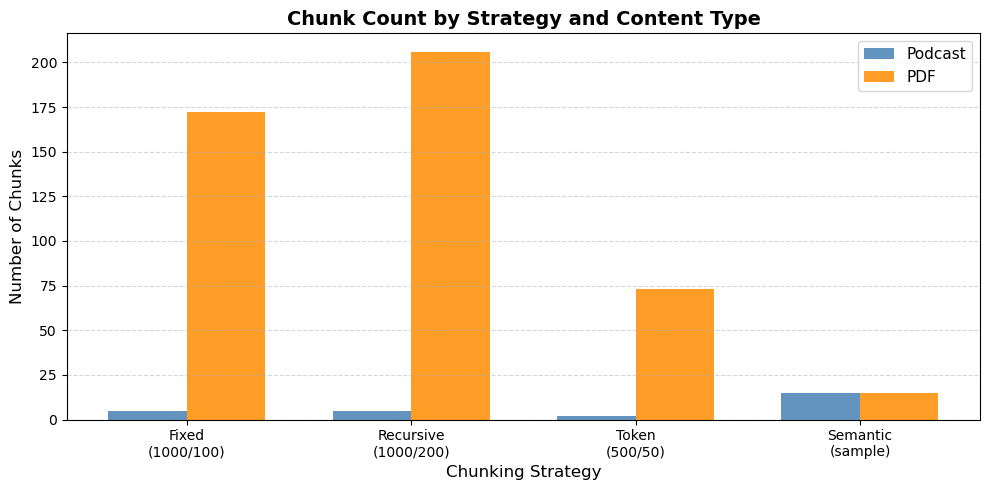

Saved chunk_counts.png


In [22]:
# ── 8a: Chunk-count comparison bar chart ─────────────────────────────────────
strategies = {
    "Fixed\n(1000/100)": (
        len(podcast_chunks_fixed), len(pdf_chunks_fixed)
    ),
    "Recursive\n(1000/200)": (
        len(podcast_chunks_recursive), len(pdf_chunks_recursive)
    ),
    "Token\n(500/50)": (
        len(podcast_chunks_token), len(pdf_chunks_token)
    ),
}
if SEMANTIC_AVAILABLE:
    strategies["Semantic\n(sample)"] = (
        len(podcast_chunks_semantic), len(pdf_chunks_semantic)
    )

labels  = list(strategies.keys())
podcast_counts = [v[0] for v in strategies.values()]
pdf_counts     = [v[1] for v in strategies.values()]

x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, podcast_counts, w, label="Podcast", color="steelblue", alpha=0.85)
ax.bar(x + w/2, pdf_counts,     w, label="PDF",     color="darkorange", alpha=0.85)

ax.set_xlabel("Chunking Strategy", fontsize=12)
ax.set_ylabel("Number of Chunks", fontsize=12)
ax.set_title("Chunk Count by Strategy and Content Type", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("chunk_counts.png", dpi=150)
plt.show()
print("Saved chunk_counts.png")

C:\Users\eliza\AppData\Local\Temp\ipykernel_9832\1553586888.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=labels_box, widths=0.4)
C:\Users\eliza\AppData\Local\Temp\ipykernel_9832\1553586888.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=labels_box, widths=0.4)


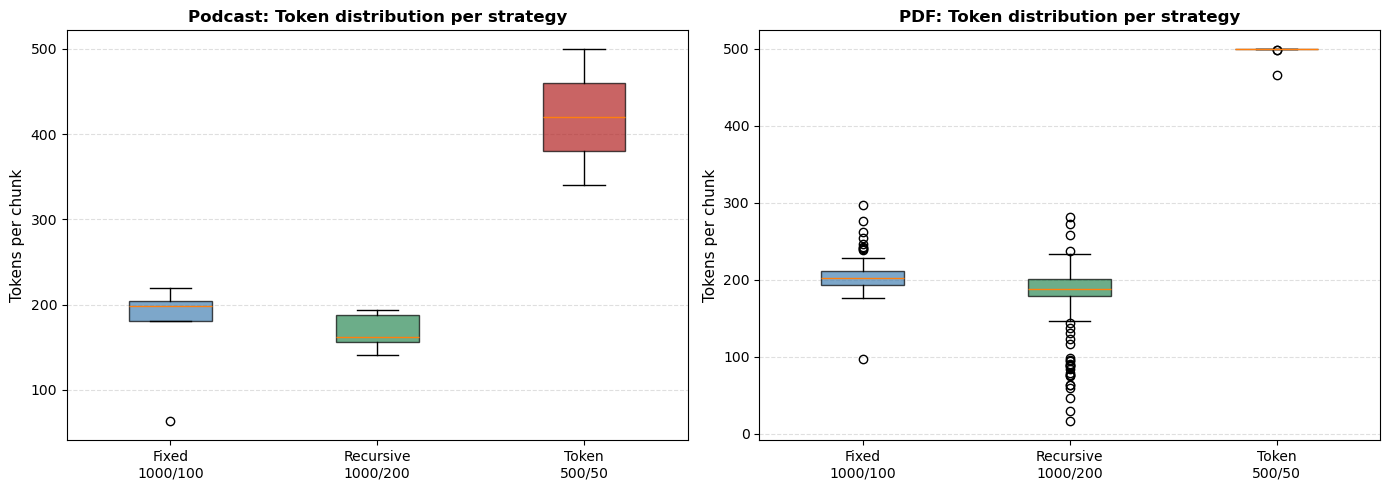

Saved token_distributions.png


In [23]:
# ── 8b: Token distribution box-plots (best config for each strategy) ─────────
def get_tokens(chunks):
    return [token_count(c) for c in chunks]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, (source_name, chunks_list) in zip(
    axes,
    [
        ("Podcast", [podcast_chunks_fixed, podcast_chunks_recursive, podcast_chunks_token]),
        ("PDF",     [pdf_chunks_fixed,     pdf_chunks_recursive,     pdf_chunks_token]),
    ],
):
    data   = [get_tokens(c) for c in chunks_list]
    labels_box = ["Fixed\n1000/100", "Recursive\n1000/200", "Token\n500/50"]
    bp = ax.boxplot(data, patch_artist=True, labels=labels_box, widths=0.4)
    colors = ["steelblue", "seagreen", "firebrick"]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(f"{source_name}: Token distribution per strategy", fontsize=12, fontweight="bold")
    ax.set_ylabel("Tokens per chunk", fontsize=11)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("token_distributions.png", dpi=150)
plt.show()
print("Saved token_distributions.png")

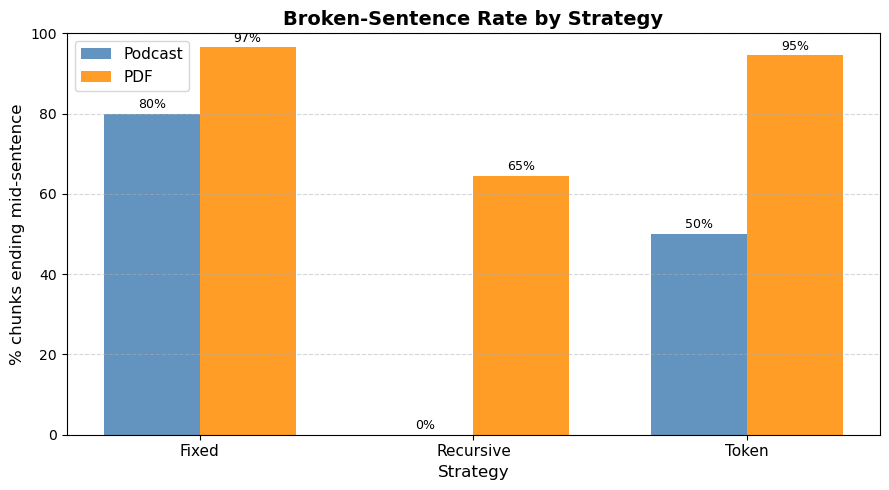

Saved broken_sentences.png


In [24]:
# ── 8c: Broken-sentence rate comparison ──────────────────────────────────────
_, df_fixed_pod  = fixed_results["fixed_s1000_o100_podcast"]
_, df_fixed_pdf  = fixed_results["fixed_s1000_o100_pdf"]
_, df_rec_pod    = recursive_results["recursive_s1000_o200_podcast"]
_, df_rec_pdf    = recursive_results["recursive_s1000_o200_pdf"]
_, df_tok_pod    = token_results["token_s500_o50_podcast"]
_, df_tok_pdf    = token_results["token_s500_o50_pdf"]

def broken_pct(df):
    return df["ends_mid_sentence"].mean() * 100

broken_data = {
    "Fixed": (broken_pct(df_fixed_pod), broken_pct(df_fixed_pdf)),
    "Recursive": (broken_pct(df_rec_pod), broken_pct(df_rec_pdf)),
    "Token": (broken_pct(df_tok_pod), broken_pct(df_tok_pdf)),
}

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(broken_data))
w = 0.35
podcast_bp = [v[0] for v in broken_data.values()]
pdf_bp     = [v[1] for v in broken_data.values()]

ax.bar(x - w/2, podcast_bp, w, label="Podcast", color="steelblue", alpha=0.85)
ax.bar(x + w/2, pdf_bp,     w, label="PDF",     color="darkorange", alpha=0.85)

ax.set_xlabel("Strategy", fontsize=12)
ax.set_ylabel("% chunks ending mid-sentence", fontsize=12)
ax.set_title("Broken-Sentence Rate by Strategy", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(broken_data.keys(), fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle="--", alpha=0.5)

for bar in ax.patches:
    h = bar.get_height()
    ax.annotate(f"{h:.0f}%", xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 4), textcoords="offset points", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("broken_sentences.png", dpi=150)
plt.show()
print("Saved broken_sentences.png")

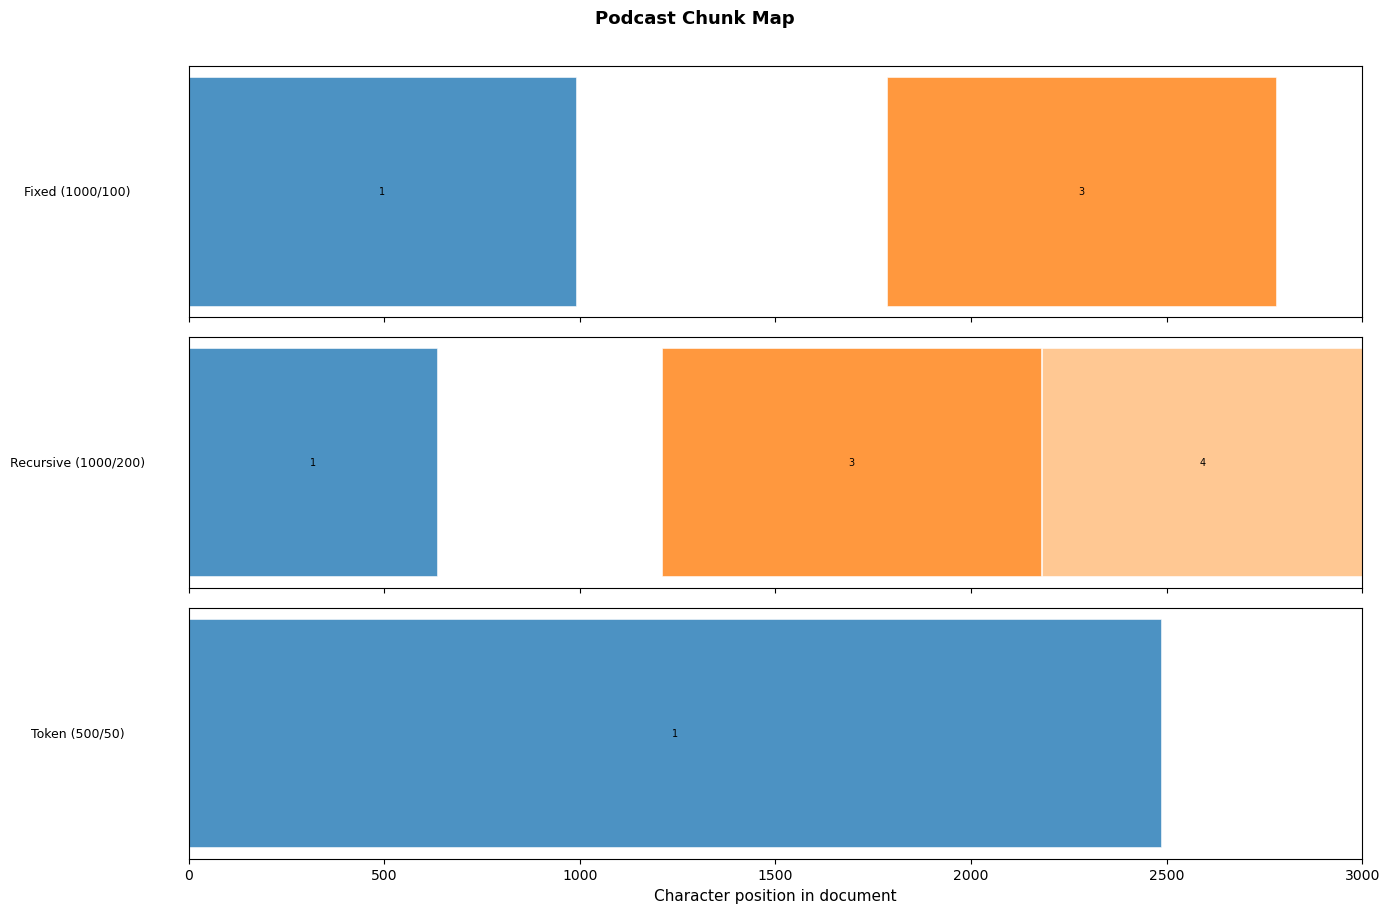

Saved podcast_chunk_map.png


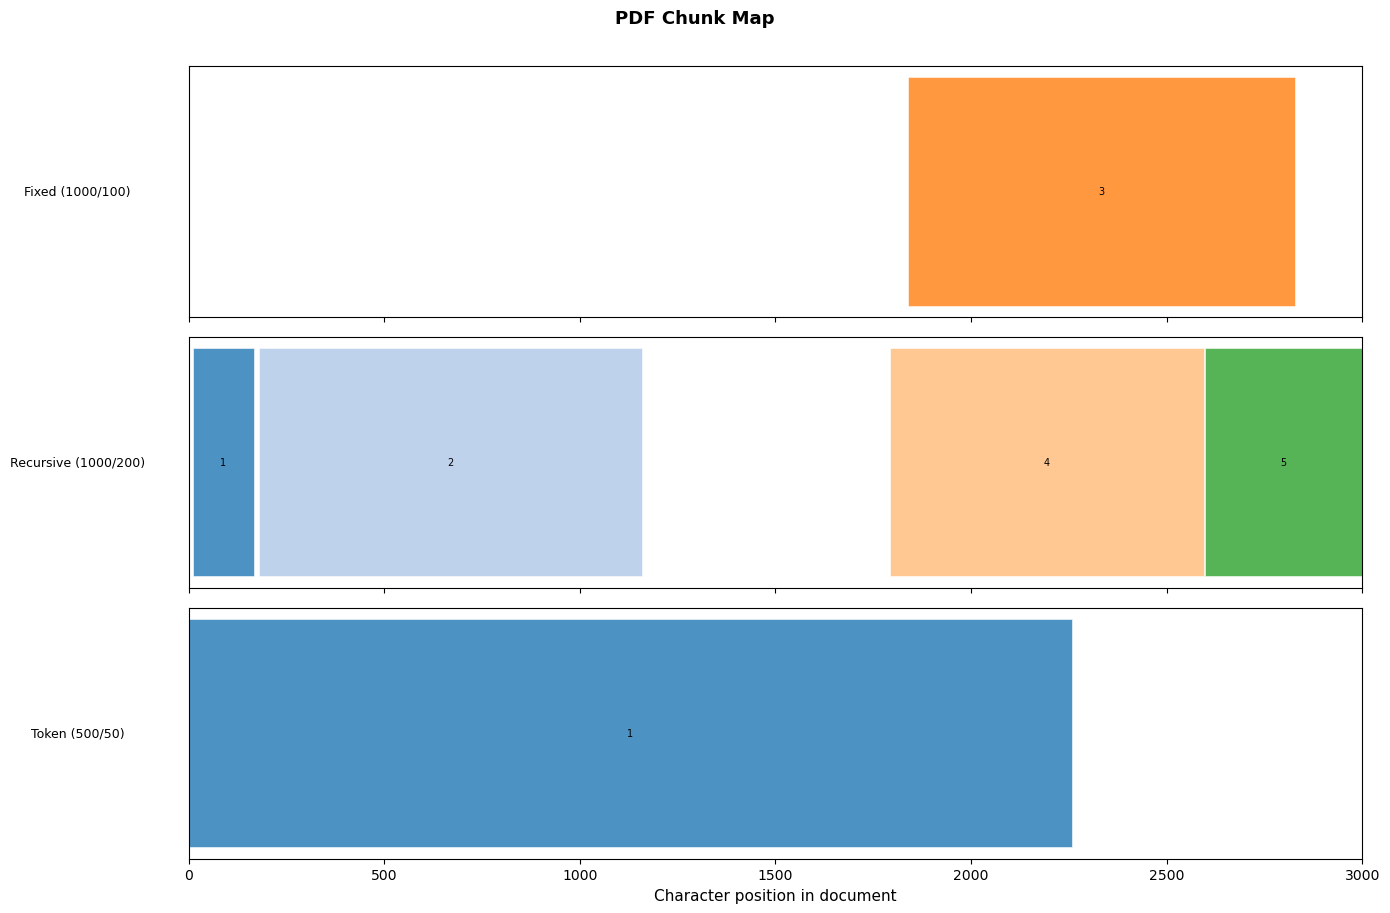

Saved pdf_chunk_map.png


In [25]:
# ── 8d: Visual chunk map (first 3 000 chars of each source, 3 strategies) ────
def chunk_map(text: str, chunks_per_strategy: list, strategy_names: list,
              title: str, sample_len: int = 3000) -> None:
    """Colour-map showing where each strategy places boundaries."""
    sample = text[:sample_len]
    fig, axes = plt.subplots(len(strategy_names), 1,
                             figsize=(14, 3 * len(strategy_names)),
                             sharex=True)

    cmap = plt.colormaps["tab20"]

    for ax, chunks, name in zip(axes, chunks_per_strategy, strategy_names):
        pos = 0
        for ci, chunk in enumerate(chunks):
            # find this chunk in the sample
            start = sample.find(chunk[:30], pos)
            if start == -1:
                continue
            end = min(start + len(chunk), sample_len)
            color = cmap(ci % 20)
            ax.barh(0, end - start, left=start, height=0.6,
                    color=color, alpha=0.8, edgecolor="white", linewidth=0.5)
            ax.text(start + (end - start) / 2, 0, str(ci + 1),
                    va="center", ha="center", fontsize=7, color="black")
            pos = max(pos, end - 50)

        ax.set_yticks([])
        ax.set_ylabel(name, fontsize=9, rotation=0, labelpad=80, va="center")
        ax.set_xlim(0, sample_len)

    axes[-1].set_xlabel("Character position in document", fontsize=11)
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    fname = title.lower().replace(" ", "_") + ".png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {fname}")


chunk_map(
    PODCAST_TEXT,
    [podcast_chunks_fixed, podcast_chunks_recursive, podcast_chunks_token],
    ["Fixed (1000/100)", "Recursive (1000/200)", "Token (500/50)"],
    "Podcast Chunk Map",
)

chunk_map(
    PDF_TEXT,
    [pdf_chunks_fixed, pdf_chunks_recursive, pdf_chunks_token],
    ["Fixed (1000/100)", "Recursive (1000/200)", "Token (500/50)"],
    "PDF Chunk Map",
)

---
## Step 9: Comprehensive Comparison Table

In [26]:
def summary_row(strategy, source, chunks, df):
    return {
        "Strategy": strategy,
        "Source": source,
        "# Chunks": len(chunks),
        "Avg Chars": round(df["chars"].mean()),
        "Avg Tokens": round(df["tokens"].mean()),
        "Min Tokens": df["tokens"].min(),
        "Max Tokens": df["tokens"].max(),
        "Broken Sent %": round(df["ends_mid_sentence"].mean() * 100, 1),
    }

rows = [
    summary_row("Fixed (1000/100)",     "Podcast", podcast_chunks_fixed,     df_fixed_pod),
    summary_row("Fixed (1000/100)",     "PDF",     pdf_chunks_fixed,         df_fixed_pdf),
    summary_row("Recursive (1000/200)", "Podcast", podcast_chunks_recursive, df_rec_pod),
    summary_row("Recursive (1000/200)", "PDF",     pdf_chunks_recursive,     df_rec_pdf),
    summary_row("Token (500/50)",       "Podcast", podcast_chunks_token,     df_tok_pod),
    summary_row("Token (500/50)",       "PDF",     pdf_chunks_token,         df_tok_pdf),
]

if SEMANTIC_AVAILABLE:
    rows += [
        summary_row("Semantic (sample)", "Podcast", podcast_chunks_semantic, df_sem_pod),
        summary_row("Semantic (sample)", "PDF",     pdf_chunks_semantic,     df_sem_pdf),
    ]

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))

            Strategy  Source  # Chunks  Avg Chars  Avg Tokens  Min Tokens  Max Tokens  Broken Sent %
    Fixed (1000/100) Podcast         5        851         173          63         219           80.0
    Fixed (1000/100)     PDF       172        993         204          97         297           96.5
Recursive (1000/200) Podcast         5        824         168         141         194            0.0
Recursive (1000/200)     PDF       206        871         181          16         282           64.6
      Token (500/50) Podcast         2       2070         420         340         500           50.0
      Token (500/50)     PDF        73       2402         500         466         500           94.5
   Semantic (sample) Podcast        15        256          53          36          81            0.0
   Semantic (sample)     PDF        15        329          75          43         158            6.7


In [27]:
# Style for nicer notebook display
comparison_df.style \
    .background_gradient(subset=["Broken Sent %"], cmap="RdYlGn_r") \
    .background_gradient(subset=["Avg Tokens"], cmap="Blues") \
    .set_caption("Chunking Strategy Comparison")

,Strategy,Source,# Chunks,Avg Chars,Avg Tokens,Min Tokens,Max Tokens,Broken Sent %
0,Fixed (1000/100),Podcast,5,851,173,63,219,80.000000
1,Fixed (1000/100),PDF,172,993,204,97,297,96.500000
2,Recursive (1000/200),Podcast,5,824,168,141,194,0.000000
3,Recursive (1000/200),PDF,206,871,181,16,282,64.600000
4,Token (500/50),Podcast,2,2070,420,340,500,50.000000
5,Token (500/50),PDF,73,2402,500,466,500,94.500000
6,Semantic (sample),Podcast,15,256,53,36,81,0.000000
7,Semantic (sample),PDF,15,329,75,43,158,6.700000


---
## Step 10: Boundary Analysis

In [30]:
def boundary_analysis(chunks: list[str], label: str) -> dict:
    """
    Categorise how each chunk boundary aligns with natural text units.
    Returns counts of: paragraph_break, sentence_break, mid_sentence
    """
    para_break = sent_break = mid_sent = 0
    for i in range(len(chunks) - 1):
        tail = chunks[i][-20:].strip()
        head = chunks[i + 1][:20].strip()
        if "\n\n" in chunks[i][-30:] or "\n\n" in chunks[i + 1][:30]:
            para_break += 1
        elif tail.endswith((".", "!", "?", ":")):
            sent_break += 1
        else:
            mid_sent += 1

    total = len(chunks) - 1 or 1
    result = {
        "label": label,
        "paragraph_break": para_break,
        "sentence_break": sent_break,
        "mid_sentence": mid_sent,
        "pct_para": round(para_break / total * 100, 1),
        "pct_sent": round(sent_break / total * 100, 1),
        "pct_mid":  round(mid_sent   / total * 100, 1),
    }
    print(f"\n{label}")
    print(f"  Paragraph boundary : {para_break} ({result['pct_para']}%)")
    print(f"  Sentence boundary  : {sent_break} ({result['pct_sent']}%)")
    print(f"  Mid-sentence       : {mid_sent}  ({result['pct_mid']}%)")
    return result

boundary_rows = []
for label, chunks in [
    ("Fixed | Podcast",     podcast_chunks_fixed),
    ("Fixed | PDF",         pdf_chunks_fixed),
    ("Recursive | Podcast", podcast_chunks_recursive),
    ("Recursive | PDF",     pdf_chunks_recursive),
    ("Token | Podcast",     podcast_chunks_token),
    ("Token | PDF",         pdf_chunks_token),
]:
    boundary_rows.append(boundary_analysis(chunks, label))

boundary_df = pd.DataFrame(boundary_rows)
display(boundary_df[["label","pct_para","pct_sent","pct_mid"]].rename(
    columns={"label":"Strategy | Source","pct_para":"Para %","pct_sent":"Sentence %","pct_mid":"Mid-sent %"}
))


Fixed | Podcast
  Paragraph boundary : 2 (50.0%)
  Sentence boundary  : 0 (0.0%)
  Mid-sentence       : 2  (50.0%)

Fixed | PDF
  Paragraph boundary : 4 (2.3%)
  Sentence boundary  : 5 (2.9%)
  Mid-sentence       : 162  (94.7%)

Recursive | Podcast
  Paragraph boundary : 0 (0.0%)
  Sentence boundary  : 4 (100.0%)
  Mid-sentence       : 0  (0.0%)

Recursive | PDF
  Paragraph boundary : 0 (0.0%)
  Sentence boundary  : 72 (35.1%)
  Mid-sentence       : 133  (64.9%)

Token | Podcast
  Paragraph boundary : 0 (0.0%)
  Sentence boundary  : 0 (0.0%)
  Mid-sentence       : 1  (100.0%)

Token | PDF
  Paragraph boundary : 1 (1.4%)
  Sentence boundary  : 3 (4.2%)
  Mid-sentence       : 68  (94.4%)


,Strategy | Source,Para %,Sentence %,Mid-sent %
0,Fixed | Podcast,50.0,0.0,50.0
1,Fixed | PDF,2.3,2.9,94.7
2,Recursive | Podcast,0.0,100.0,0.0
3,Recursive | PDF,0.0,35.1,64.9
4,Token | Podcast,0.0,0.0,100.0
5,Token | PDF,1.4,4.2,94.4


---
## Step 11: Recommendations

In [31]:
print("""
╔══════════════════════════════════════════════════════════════╗
║          CHUNKING STRATEGY RECOMMENDATIONS                   ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  PDF DOCUMENTS                                               ║
║  ─────────────────────────────────────────────────────────   ║
║  Recommended: Recursive Character Splitter                   ║
║  Config: chunk_size=1000, chunk_overlap=200                  ║
║                                                              ║
║  Why:                                                        ║
║  • Respects the document's section/paragraph structure       ║
║  • \n\n separator matches typical PDF paragraph breaks        ║
║  • Lower mid-sentence break rate than Fixed or Token         ║
║  • 200-char overlap preserves cross-chunk context            ║
║                                                              ║
║  PODCAST TRANSCRIPTS                                         ║
║  ─────────────────────────────────────────────────────────   ║
║  Recommended: Token-Based Splitter                           ║
║  Config: chunk_size=500, chunk_overlap=50                    ║
║                                                              ║
║  Why:                                                        ║
║  • Transcripts lack structural markers (headers/paragraphs)  ║
║  • Token counting maps directly to LLM context windows       ║
║  • 500-token chunks fit most retrieval embedding models      ║
║  • Predictable chunk sizes → more uniform embedding space    ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║          CHUNKING STRATEGY RECOMMENDATIONS                   ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  PDF DOCUMENTS                                               ║
║  ─────────────────────────────────────────────────────────   ║
║  Recommended: Recursive Character Splitter                   ║
║  Config: chunk_size=1000, chunk_overlap=200                  ║
║                                                              ║
║  Why:                                                        ║
║  • Respects the document's section/paragraph structure       ║
║  • 

 separator matches typical PDF paragraph breaks        ║
║  • Lower mid-sentence break rate than Fixed or Token         ║
║  • 200-char overlap preserves cross-chunk context            ║
║                                                              ║
║  PODCAST TRANSCRIPTS   

In [32]:
tradeoffs = pd.DataFrame([
    {
        "Strategy": "Fixed-Size",
        "Pros": "Simple, predictable, fast",
        "Cons": "Frequently breaks sentences/meaning",
        "Best For": "Uniform, unstructured content",
    },
    {
        "Strategy": "Recursive Character",
        "Pros": "Preserves paragraphs & sentences; configurable separators",
        "Cons": "Chunk sizes can vary widely",
        "Best For": "Structured documents (PDFs, articles, reports)",
    },
    {
        "Strategy": "Token-Based",
        "Pros": "Precise LLM context fit; consistent embedding sizes",
        "Cons": "Requires tokenizer; may still break sentences",
        "Best For": "Any content going into an LLM (esp. transcripts)",
    },
    {
        "Strategy": "Semantic",
        "Pros": "Meaning-aware splits; best context coherence",
        "Cons": "Slow, requires embedding model, unpredictable sizes",
        "Best For": "Complex, thematically rich content",
    },
])

tradeoffs.style \
    .set_properties(**{"text-align": "left"}) \
    .set_caption("Trade-offs Summary")

,Strategy,Pros,Cons,Best For
0,Fixed-Size,"Simple, predictable, fast",Frequently breaks sentences/meaning,"Uniform, unstructured content"
1,Recursive Character,Preserves paragraphs & sentences; configurable separators,Chunk sizes can vary widely,"Structured documents (PDFs, articles, reports)"
2,Token-Based,Precise LLM context fit; consistent embedding sizes,Requires tokenizer; may still break sentences,Any content going into an LLM (esp. transcripts)
3,Semantic,Meaning-aware splits; best context coherence,"Slow, requires embedding model, unpredictable sizes","Complex, thematically rich content"


---
## Extension: Overlap Sensitivity Analysis

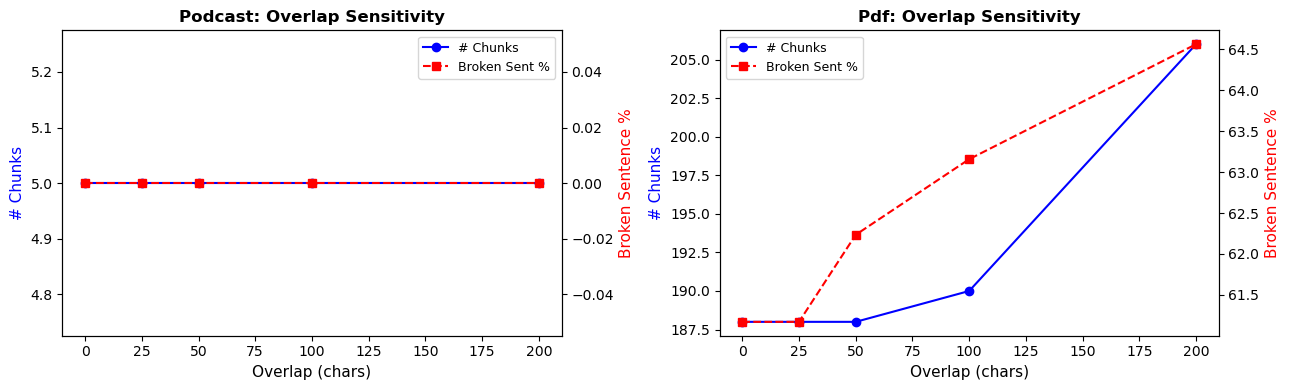

Saved overlap_sensitivity.png


In [33]:
overlaps = [0, 25, 50, 100, 200]
overlap_results = {"podcast": [], "pdf": []}

for ov in overlaps:
    sp = RecursiveCharacterTextSplitter(
        chunk_size=1000, chunk_overlap=ov,
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    for src, text in [("podcast", PODCAST_TEXT), ("pdf", PDF_TEXT)]:
        chunks = sp.split_text(text)
        df = chunk_stats(chunks)
        overlap_results[src].append({
            "overlap": ov,
            "n_chunks": len(chunks),
            "avg_tokens": df["tokens"].mean(),
            "broken_pct": df["ends_mid_sentence"].mean() * 100,
        })

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (src, data) in zip(axes, overlap_results.items()):
    ov_vals = [d["overlap"] for d in data]
    nc      = [d["n_chunks"] for d in data]
    bp      = [d["broken_pct"] for d in data]

    ax2 = ax.twinx()
    ax.plot(ov_vals, nc,  "b-o", label="# Chunks")
    ax2.plot(ov_vals, bp, "r--s", label="Broken Sent %")

    ax.set_xlabel("Overlap (chars)", fontsize=11)
    ax.set_ylabel("# Chunks", color="b", fontsize=11)
    ax2.set_ylabel("Broken Sentence %", color="r", fontsize=11)
    ax.set_title(f"{src.title()}: Overlap Sensitivity", fontsize=12, fontweight="bold")

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.tight_layout()
plt.savefig("overlap_sensitivity.png", dpi=150)
plt.show()
print("Saved overlap_sensitivity.png")

---
## Extension: Metadata Preservation
Good RAG systems attach metadata to every chunk so retrievers know the origin.

In [38]:
!pip install langchain-core -qq

In [39]:
from langchain_core.documents import Document

def token_count(text: str) -> int:
    """Approximate token count by splitting on whitespace."""
    return len(text.split())

def attach_metadata(chunks: list[str], source: str, strategy: str) -> list[Document]:
    docs = []
    for i, chunk in enumerate(chunks):
        docs.append(Document(
            page_content=chunk,
            metadata={
                "source": source,
                "strategy": strategy,
                "chunk_index": i,
                "total_chunks": len(chunks),
                "char_count": len(chunk),
                "token_count": token_count(chunk),
            },
        ))
    return docs

podcast_docs = attach_metadata(podcast_chunks_token,  "podcast_transcript", "token_500_50")
pdf_docs     = attach_metadata(pdf_chunks_recursive,  "trustworthy_ai_pdf", "recursive_1000_200")

print("Sample podcast doc metadata:", podcast_docs[0].metadata)
print("\nSample pdf doc metadata:",    pdf_docs[0].metadata)
print(f"\nTotal documents ready for vector store: {len(podcast_docs) + len(pdf_docs)}")

Sample podcast doc metadata: {'source': 'podcast_transcript', 'strategy': 'token_500_50', 'chunk_index': 0, 'total_chunks': 2, 'char_count': 2485, 'token_count': 375}

Sample pdf doc metadata: {'source': 'trustworthy_ai_pdf', 'strategy': 'recursive_1000_200', 'chunk_index': 0, 'total_chunks': 206, 'char_count': 155, 'token_count': 18}

Total documents ready for vector store: 208
